<div style="width: 100%; clear: both;">
    <div style="float: left; width: 50%;">
       <img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
    </div>
</div>

<div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;">22.501 · Fundamentos de Programación</p>
    <p style="margin: 0; text-align:right;">Grado en Ciencia de Datos Aplicada</p>
    <p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
    <p style="margin: 0; text-align:right; padding-button: 100px;"> María Victoria Vivas Gutiérrez</p>
</div>

</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

Actividad 5. Adquisición y Visualización de datos
========


Fundamentos de Programación
============================


En este Notebook se encontraréis el conjunto de actividades evaluables como PEC de la asignatura. Veréis que cada una de ellas tiene asociada una puntuación, que indica el peso que tiene la actividad sobre la nota final de la PEC. Adicionalmente, hay un ejercicio opcional, que no tiene puntuación dentro de la PEC, pero que se valora al final del semestre de cara a conceder las matrículas de honor y redondear las notas finales. Podréis sacar la máxima nota de la PEC sin necesidad de hacer este ejercicio. El objetivo de este ejercicio es que sirva como pequeño reto para los estudiantes que quieran profundizar en el contenido de la asignatura.

Veréis que todas las actividades de la PEC tienen una etiqueta, que indica los recursos necesarios para llevarla a cabo. Hay tres posibles etiquetas:

* <span style="font-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **Sólo materiales**: las herramientas necesarias para realizar la actividad se pueden encontrar en los materiales de la asignatura.

* <span style = "font-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 3px; ">EG</span> **Consulta externa guiada**: la actividad puede requerir hacer uso de herramientas que no se encuentran en los materiales de la asignatura, pero el enunciado contiene indicaciones de dónde o cómo encontrar la información adicional necesaria para resolver la actividad.

* <span style = "font-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px;">EI</span> **Consulta externa independiente**: la actividad puede requerir hacer uso de herramientas que no se encuentran en los materiales de la asignatura, y el enunciado puede no incluir la descripción de dónde o cómo encontrar esta información adicional. Será necesario que el estudiante busque esta información utilizando los recursos que se han explicado en la asignatura.

Es importante notar que estas etiquetas no indican el nivel de dificultad del ejercicio, sino únicamente la necesidad de consulta de documentación externa para su resolución. Además, recordad que las **etiquetas son informativas**, pero podréis consultar referencias externas en cualquier momento (aunque no se indique explícitamente) o puede ser que podáis hacer una actividad sin consultar ningún tipo de documentación. Por ejemplo, para resolver una actividad que sólo requiera los materiales de la asignatura, puedéis consultar referencias externas si queréis, ya sea tanto para ayudaros en la resolución como para ampliar el conocimiento!

En cuanto a la consulta de documentación externa en la resolución de los ejercicios, recordad **citar siempre la bibliografía utilizada** para resolver cada actividad.

---

In [ ]:
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# LIBRERÍAS NECESARIAS
import requests
import pandas as pd
import time
from tqdm import tqdm
from datetime import datetime, timedelta
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
from geopy.distance import geodesic
import ipywidgets as widgets
from IPython.display import display

### Ejercicio 1 (2.5 puntos)


Considera la siguiente API, localizada en [`vatcomply`](https://www.vatcomply.com/documentation). Realiza las siguientes tareas usando llamadas a la API:

a) Haz un llamamiento para recuperar las monedas disponibles en la API. Muestra las monedas en formato de una lista y mostrando sólo su nombre corto (`EUR`).


<span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **0.5 puntos**


In [ ]:
# 1. Get the URL de las currencies
URL = "https://api.vatcomply.com/currencies"
response = requests.get(URL)

# 2. Mostrar JSON con todas las monedas
print(response.json())

{'EUR': {'name': 'Euro', 'symbol': 'EUR'}, 'USD': {'name': 'US Dollar', 'symbol': 'USD'}, 'JPY': {'name': 'Japanese Yen', 'symbol': 'JPY'}, 'BGN': {'name': 'Bulgarian Lev', 'symbol': 'BGN'}, 'CZK': {'name': 'Czech Koruna', 'symbol': 'CZK'}, 'DKK': {'name': 'Danish Krone', 'symbol': 'DKK'}, 'GBP': {'name': 'British Pound', 'symbol': 'GBP'}, 'HUF': {'name': 'Hungarian Forint', 'symbol': 'HUF'}, 'PLN': {'name': 'Polish Zloty', 'symbol': 'PLN'}, 'RON': {'name': 'Romanian Leu', 'symbol': 'RON'}, 'SEK': {'name': 'Swedish Krona', 'symbol': 'SEK'}, 'CHF': {'name': 'Swiss Franc', 'symbol': 'CHF'}, 'ISK': {'name': 'Icelandic Króna', 'symbol': 'ISK'}, 'NOK': {'name': 'Norwegian Krone', 'symbol': 'NOK'}, 'HRK': {'name': 'Croatian Kuna', 'symbol': 'HRK'}, 'RUB': {'name': 'Russian Ruble', 'symbol': 'RUB'}, 'TRY': {'name': 'Turkish Lira', 'symbol': 'TRY'}, 'AUD': {'name': 'Australian Dollar', 'symbol': 'AUD'}, 'BRL': {'name': 'Brazilian Real', 'symbol': 'BRL'}, 'CAD': {'name': 'Canadian Dollar', 'sym

b) Recupera en un diccionario los valores de cada moneda, de forma que la clave sea el nombre corto (`EUR`), y los valores sean otro diccionario con las claves `name` con el nombre largo de la moneda (`EURO`), `symbol` con su correspondiente símbolo (`€`) y `value` con el valor relativo a `EUR`. Encapsula este código en una función que tenga como parámetro de entrada una fecha y una lista de las monedas a recuperar en formato corto (`EUR`), así como la moneda base a la que referir los valores (`EUR`). Llama la función con la entrada del día de hoy, con todas las monedas posibles y en base al EUR. Informa al usuario de los problemas que puedan surgir.

<span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span>(**1 punto**)

In [ ]:
# 1. Función
def obtener_valores_monedas(fecha, monedas, base="EUR"):
    """
    Recupera los valores de cambio de las monedas en relación con la moneda base.

    Parámetros:
    - fecha (str): Fecha en formato 'YYYY-MM-DD'.
    - monedas (list): Lista de códigos de moneda en formato corto ('EUR', 'USD', etc.).
    - base (str): Moneda base para los valores de cambio (por defecto, 'EUR').

    Retorna:
    - Diccionario con los valores de cada moneda.
    """

    # URL de la API con la fecha y la moneda base
    url = f"https://api.vatcomply.com/rates?date={fecha}&base={base}"

    try:
        response = requests.get(url)  # Realizar solicitud GET
        response.raise_for_status()  # Verificar si hay errores en la petición

        datos = response.json()  # Convertir respuesta a JSON
        tasas = datos.get("rates", {})  # Extraer las tasas de cambio

        # Obtener las monedas disponibles en la API
        url_monedas = "https://api.vatcomply.com/currencies"
        response_monedas = requests.get(url_monedas)
        response_monedas.raise_for_status()

        info_monedas = response_monedas.json()  # Diccionario

        # Construir el diccionario con la información solicitada
        resultado = {}
        for moneda in monedas:
            if moneda in tasas and moneda in info_monedas:
                resultado[moneda] = {
                    "name": info_monedas[moneda]["name"],
                    "symbol": info_monedas[moneda]["symbol"],
                    "value": tasas[moneda]
                }
            else:
                print(f"Advertencia: La moneda '{moneda}' no está disponible.")

        return resultado

    except requests.exceptions.RequestException as e:
        print(f"Error en la solicitud a la API: {e}")
        return {}

In [ ]:
# 1. Obtener la fecha de hoy
from datetime import datetime
fecha_hoy = datetime.today().strftime('%Y-%m-%d')

# 2. Obtener la lista de monedas disponibles
url_monedas = "https://api.vatcomply.com/currencies"
response_monedas = requests.get(url_monedas)
monedas_disponibles = list(response_monedas.json().keys())

# 3. Llamar a la función con todas las monedas y base EUR
datos_monedas = obtener_valores_monedas(fecha_hoy, monedas_disponibles, "EUR")

# 4. Mostrar los resultados
print(datos_monedas)

Advertencia: La moneda 'HRK' no está disponible.
Advertencia: La moneda 'RUB' no está disponible.
{'EUR': {'name': 'Euro', 'symbol': 'EUR', 'value': 1.0}, 'USD': {'name': 'US Dollar', 'symbol': 'USD', 'value': 1.1411}, 'JPY': {'name': 'Japanese Yen', 'symbol': 'JPY', 'value': 164.62}, 'BGN': {'name': 'Bulgarian Lev', 'symbol': 'BGN', 'value': 1.9558}, 'CZK': {'name': 'Czech Koruna', 'symbol': 'CZK', 'value': 24.757}, 'DKK': {'name': 'Danish Krone', 'symbol': 'DKK', 'value': 7.4595}, 'GBP': {'name': 'British Pound', 'symbol': 'GBP', 'value': 0.8426}, 'HUF': {'name': 'Hungarian Forint', 'symbol': 'HUF', 'value': 403.15}, 'PLN': {'name': 'Polish Zloty', 'symbol': 'PLN', 'value': 4.287}, 'RON': {'name': 'Romanian Leu', 'symbol': 'RON', 'value': 5.0452}, 'SEK': {'name': 'Swedish Krona', 'symbol': 'SEK', 'value': 10.959}, 'CHF': {'name': 'Swiss Franc', 'symbol': 'CHF', 'value': 0.9383}, 'ISK': {'name': 'Icelandic Króna', 'symbol': 'ISK', 'value': 144.2}, 'NOK': {'name': 'Norwegian Krone', 's

c) Haz una función que use la función anterior, y ejecute una solicitud de los valores de todas las monedas relativas a `EUR` diarios para todo el año 2024 hasta el 30 de abril de 2025. Haz las llamadas de forma que:

- Con el fin de no saturar el servidor, realizaremos una espera de `0.5s` entre solicitud y solicitud.
- La salida debe devolver un dataframe, con un índice en forma de `Datetime`
- La llamada debe usar una barra de progreso usando la librería `tqdm` (`tqdm` deriva de la palabra en Arabic *taqaddum* (تقدّم) que puede significar "progreso," y es una abreviación de *te quiero demasiado* en Castellano ) mira la documentación para estudiar su uso
- Toma las decisiones que creas oportunas en la construcción del objeto de pandas y jústificales.

<span style="fuente-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 3px; ">EG</span>
(**1 punto**)

In [ ]:
# 1. Función que obtiene tasas de cambio de una
# lista de monedas en una fecha específica
def obtener_valores_monedas(fecha, monedas, base="EUR"):
    """
    Recupera las tasas de cambio de monedas en
    relación con la moneda base en una fecha específica.

    Parámetros:
    - fecha (str): Fecha en formato 'YYYY-MM-DD'
    - monedas (list): Lista de códigos de moneda ('USD', 'JPY', etc.)
    - base (str): Moneda base para las conversiones ('EUR' por defecto)

    Retorna:
    - Diccionario con valores de cambio, nombres y símbolos de las monedas.
    """

    # 1.1. Construimos la URL para consultar tasas en una fecha específica
    url = f"https://api.vatcomply.com/rates?date={fecha}&base={base}"

    try:
        # 1.2. Realizamos la solicitud GET a la API para obtener tasas
        response = requests.get(url)
        response.raise_for_status()  # Verifica que la solicitud fue exitosa

        # 1.3. Convertimos la respuesta a formato JSON y extraemos las tasas
        datos = response.json()
        tasas = datos.get("rates", {})  # Diccionario con tasas de cambio

        # 1.4. Hacemos otra solicitud para obtener nombres y símbolos de monedas
        url_monedas = "https://api.vatcomply.com/currencies"
        response_monedas = requests.get(url_monedas)
        response_monedas.raise_for_status()

        # 1.5. Convertimos la respuesta a JSON
        info_monedas = response_monedas.json()

        # 1.6. Construimos un diccionario con la información de cada moneda
        resultado = {}
        for moneda in monedas:
            if moneda in tasas and moneda in info_monedas:
                resultado[moneda] = {
                    "name": info_monedas[moneda]["name"],
                    "symbol": info_monedas[moneda]["symbol"],
                    "value": tasas[moneda]
                }
            else:
                resultado[moneda] = {"name": None,
                                     "symbol": None, "value": None}

        return resultado

    except requests.exceptions.RequestException as e:
        print(f" Error en la solicitud de {fecha}: {e}")
        return {}

# 2. Función que recupera datos de monedas desde 2024-01-01 hasta 2025-04-30
def obtener_datos_ano():
    """
    Obtiene y estructura los valores de monedas
    en relación con EUR desde 2024-01-01 hasta 2025-04-30.

    Retorna:
    - DataFrame de pandas con las tasas de cambio para cada fecha.
    """

    # 2.1. Definimos el rango de fechas a analizar
    fecha_inicio = datetime(2024, 1, 1)  # Fecha de inicio
    fecha_fin = datetime(2025, 4, 30)    # Fecha de fin

    # 2.2. Obtenemos la lista de monedas disponibles desde la API
    # Extraemos solo los códigos de moneda
    url_monedas = "https://api.vatcomply.com/currencies"
    response_monedas = requests.get(url_monedas)
    monedas_disponibles = list(response_monedas.json().keys())
    data = []  # 3.3. Lista para almacenar los datos de cada día
    fechas = []  # Lista para almacenar todas las fechas del periodo

    # 2.3. Generamos todas las fechas entre 2024-01-01 y 2025-04-30
    fecha_actual = fecha_inicio
    while fecha_actual <= fecha_fin:
        fechas.append(fecha_actual.strftime('%Y-%m-%d'))  # Convertimos la fecha a string
        fecha_actual += timedelta(days=1)  # Avanzamos un día

    # 2.4. Iteramos sobre cada fecha y recuperamos los valores de las monedas
    for fecha in tqdm(fechas, desc="Recuperando datos de monedas", unit="día"):
        valores = obtener_valores_monedas(fecha, monedas_disponibles, "EUR")

        # 2.5. Convertimos los datos a un formato adecuado para pandas
        fila = {"date": fecha}  # Iniciamos un diccionario con la fecha
        for moneda, detalles in valores.items():
            fila[f"{moneda}_value"] = detalles["value"]  # Guardamos el valor de cambio

        data.append(fila)  # 3.7. Agregamos la fila a la lista de datos

        time.sleep(0.5)  # 3.8. Esperamos 0.5 segundos entre cada solicitud para no saturar el servidor

    # 2.6. Convertimos la lista de datos en un DataFrame de pandas
    df = pd.DataFrame(data)

    # 2.7. Convertimos la columna "date" en DatetimeIndex para análisis temporal
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)  # Establecemos la fecha como índice

    return df

# 3. Ejecutamos la función para recuperar datos de monedas en el periodo definido
df_monedas = obtener_datos_ano()

# 4. Mostramos las primeras filas del DataFrame resultante
print(df_monedas.head())  # Muestra las primeras 5 filas

Recuperando datos de monedas: 100%|██████████| 486/486 [07:16<00:00,  1.11día/s]

            EUR_value  USD_value  JPY_value  BGN_value  CZK_value  DKK_value  \
date                                                                           
2024-01-01        1.0     1.1050     156.33     1.9558     24.724     7.4529   
2024-01-02        1.0     1.0956     155.68     1.9558     24.687     7.4551   
2024-01-03        1.0     1.0919     156.16     1.9558     24.675     7.4581   
2024-01-04        1.0     1.0953     157.91     1.9558     24.652     7.4590   
2024-01-05        1.0     1.0921     158.57     1.9558     24.616     7.4584   

            GBP_value  HUF_value  PLN_value  RON_value  ...  ILS_value  \
date                                                    ...              
2024-01-01    0.86905     382.80     4.3395     4.9756  ...     3.9993   
2024-01-02    0.86645     382.10     4.3708     4.9705  ...     3.9705   
2024-01-03    0.86470     380.75     4.3638     4.9725  ...     3.9867   
2024-01-04    0.86278     378.85     4.3460     4.9733  ...     3.997

**Nota**: En el Dataframe la moneda base es el Euro.

### Ejercicio 2 (3.5 puntos)

A partir del dataframe de pandas que has obtenido en el ejercicio anterior. Realiza las siguientes visualizaciones descriptivas:

a) Muestra la estadística descriptiva por cada moneda.

<span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span>(**0.5 puntos**)

In [ ]:
# 1. Mostrar la estadística descriptiva de cada moneda
print(df_monedas.describe())

       EUR_value   USD_value   JPY_value     BGN_value   CZK_value  \
count      486.0  486.000000  486.000000  4.860000e+02  486.000000   
mean         1.0    1.079199  163.106358  1.955800e+00   25.107605   
std          0.0    0.024706    4.023718  1.733733e-14    0.207588   
min          1.0    1.019800  155.660000  1.955800e+00   24.488000   
25%          1.0    1.065300  160.560000  1.955800e+00   25.009000   
50%          1.0    1.082550  162.345000  1.955800e+00   25.140000   
75%          1.0    1.091575  164.620000  1.955800e+00   25.270750   
max          1.0    1.147600  175.390000  1.955800e+00   25.460000   

        DKK_value   GBP_value   HUF_value   PLN_value   RON_value  ...  \
count  486.000000  486.000000  486.000000  486.000000  486.000000  ...   
mean     7.459452    0.845126  397.876955    4.284001    4.975165  ...   
std      0.002656    0.010730    9.027072    0.052277    0.002446  ...   
min      7.452900    0.824280  377.650000    4.130800    4.964400  ...   

b) Grafica la relación "USD/EUR" por todo el tiempo descargado usando matplotlib, asegurado de poner las etiquetas correspondientes para que se pueda interpretar correctamente en el gráfico. Discute el resultado que observas.

<span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span>(**0.5 puntos**)


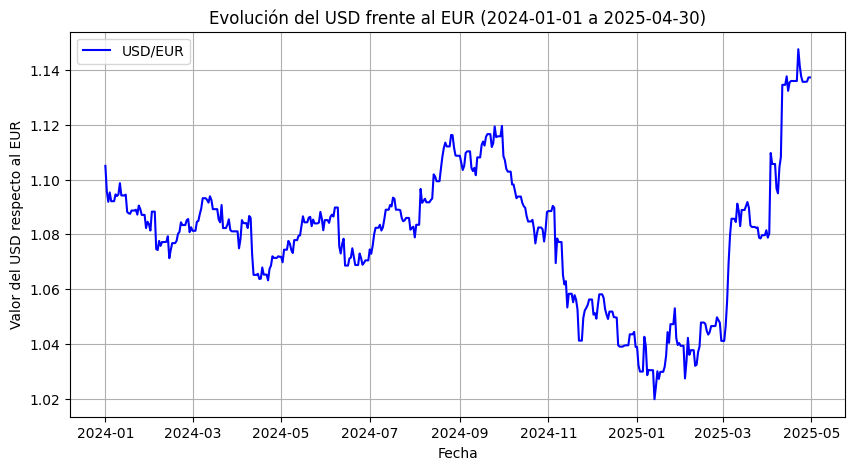

In [ ]:
# 1.Crear la figura y el gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_monedas.index, df_monedas["USD_value"], label="USD/EUR", color="blue", linestyle="-")

# 2. Configurar etiquetas y título
plt.xlabel("Fecha")
plt.ylabel("Valor del USD respecto al EUR")
plt.title("Evolución del USD frente al EUR (2024-01-01 a 2025-04-30)")
plt.legend()
plt.grid(True)

# 3. Mostrar el gráfico
plt.show()

Trump heredó unos valores relativamente estables en la relación en el dólar de la administración Biden. A partir de marzo/abril 2025, surgieron grandes caídas en el sentimiento de los consumidores y aumento de las mayores expectativas de tasas de inflación entre los consumidores y los economistas de Wall Street debido a sus políticas arancelarias, que finalmente provocó una caída del mercado de valores en abril tras el anuncio de las tarifas USD.

**RESPUESTA**

El análisis muestra que el EUR se ha fortalecido frente al USD, alcanzando un tipo de cambio de 1.14 USD/EUR. Esto indica una depreciación del dólar, posiblemente influenciada por factores como política monetaria de la Fed, inflación en EE.UU. y estabilidad económica en la Eurozona. La coincidencia con fuentes como TradingView (donde se inspecciona la relación de este valor por minuto) valida la precisión del análisis.

c) Grafica la relación de ratos por las siguientes monedas:

```
["US Dollar", "British Pound", "Swiss Franc",
"Australian Dollar", "Canadian Dollar", "Chinese Yuan",
"Hong Kong Dollar", "Singapore Dollar"]
```
por el tiempo descargado usando matplotlib, asegurado de poner las etiquetas correspondientes para que se pueda interpretar correctamente el gráfico. Recupera los códigos de las monedas usando la API.

<span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span>(**0.5 puntos**)


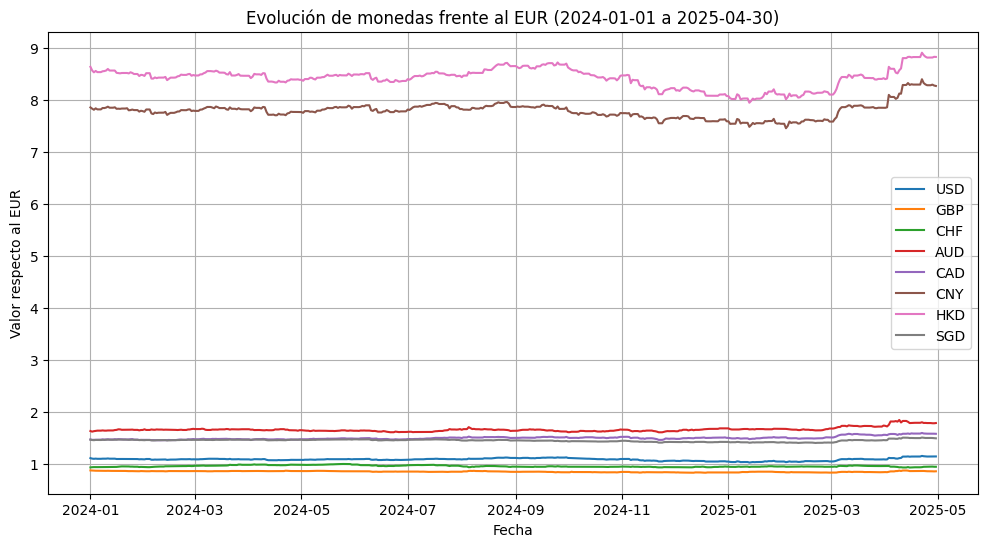

In [ ]:
# 1. Definimos la lista de monedas que queremos graficar
monedas_a_graficar = ["USD_value", "GBP_value", "CHF_value", "AUD_value",
                       "CAD_value", "CNY_value", "HKD_value", "SGD_value"]

# 2. Creamos una figura para el gráfico
plt.figure(figsize=(12, 6))

# 3. Iteramos sobre cada moneda y la graficamos
for moneda in monedas_a_graficar:
    plt.plot(df_monedas.index, df_monedas[moneda],
             label=moneda.replace("_value", ""), linestyle="-")

# 4. Configuramos etiquetas, título, leyenda y cuadrícula
plt.xlabel("Fecha")  # Etiqueta en el eje X (Tiempo)
plt.ylabel("Valor respecto al EUR")  # Etiqueta en el eje Y (Tasa de cambio)
plt.title(
    "Evolución de monedas frente al EUR (2024-01-01 a 2025-04-30)"
    )  # Título del gráfico

plt.legend()
plt.grid(True)
plt.show()

d) Calcula la correlación de los ratios largo del tiempo. Calcula esta correlación entre todas las monedas y visualiza la matriz de correlación de forma clusterizada con la función `clustermap` de seaborn. Visualmente, ¿qué monedas aparecen menos correladas con el resto? revisa que el mapa de color debe ser interpretable correctamente.

<span style="fuente-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 3px; ">EG</span>
**(1 punto)**

Monedas con más del 50% de correlaciones NaN: ['EUR_value', 'BGN_value', 'HRK_value', 'RUB_value']


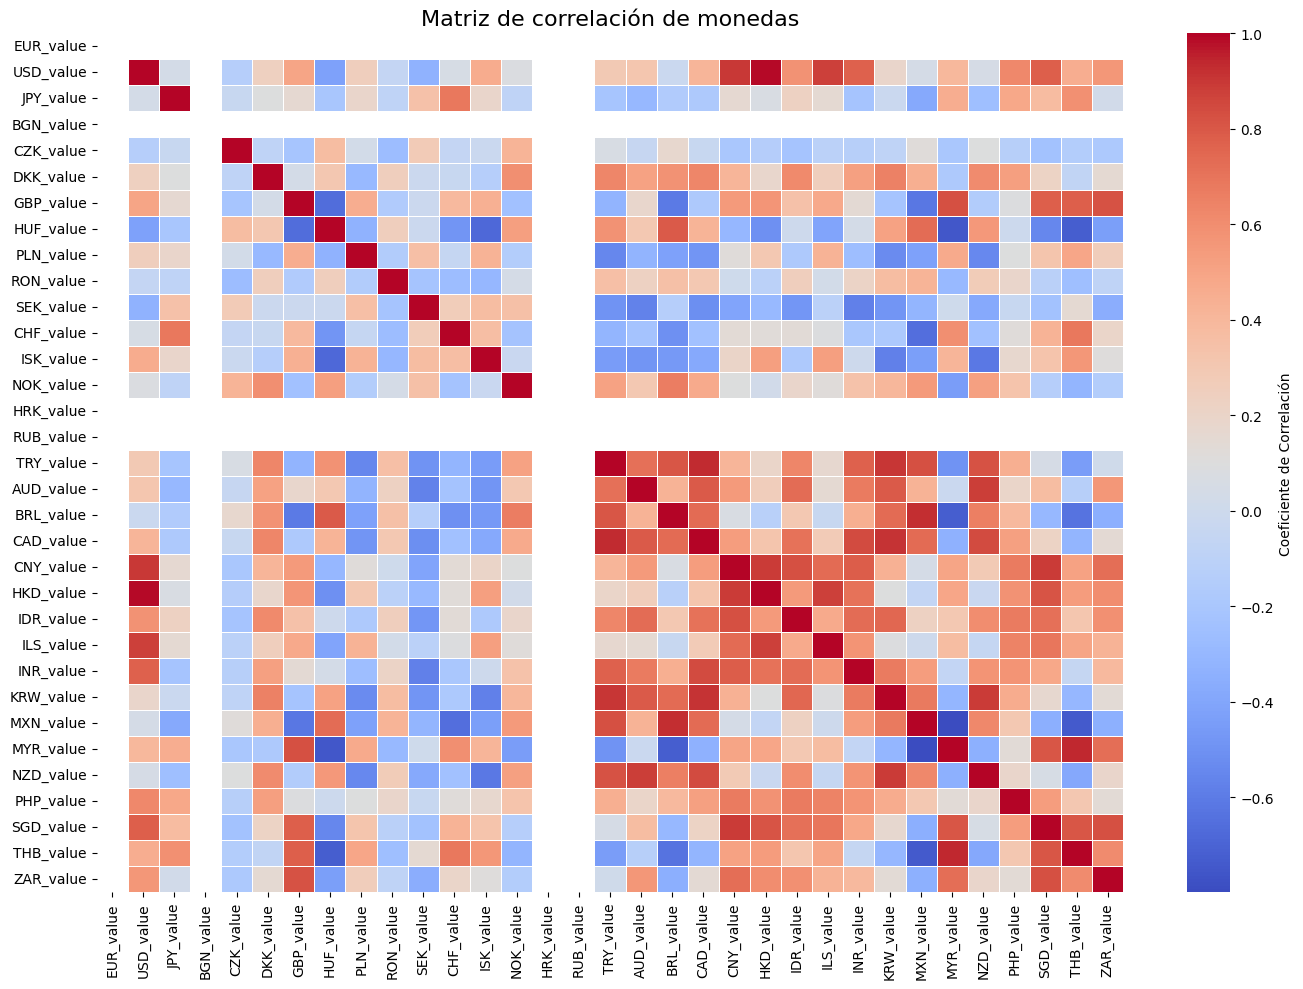

In [ ]:
# 1. Calcular la matriz de correlación entre las monedas.
correlacion_monedas = df_monedas.corr()

# 2️. Identificar las columnas/filas (monedas) con un alto porcentaje de NaN.
nan_counts = correlacion_monedas.isnull().sum() # Contar NaNs por columna
# Identificar columnas donde más del 50% de las correlaciones son NaN
cols_with_high_nan_corr = nan_counts[
    nan_counts / len(correlacion_monedas) > 0.5].index

print(f"Monedas con más del 50% de correlaciones NaN: {list(cols_with_high_nan_corr)}")

# 3️. Visualizar la matriz de correlación usando seaborn.heatmap.
# Esta función crea un mapa de calor a partir de la matriz.
# Los valores NaN en la matriz se mostrarán con un color específico
#(generalmente blanco o gris,dependiendo del mapa de color)
# indicando que la correlación no pudo ser calculada.

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlacion_monedas,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

# 4️. Configurar el título y ajustar las etiquetas de los ejes para mejor legibilidad
plt.title("Matriz de correlación de monedas", fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# 5️. Mostrar el gráfico
plt.tight_layout()
plt.show()

La matriz de correlación muestra que EUR, BGN, RUB y HRK tienen un valor de 1.000, lo que indica que están perfectamente correlacionadas consigo mismas, lo cual es esperable. Este valor podría ser resultado de una falta de variabilidad en los datos de estas monedas, generando una autocorrelación artificialmente alta.

Más allá de estas monedas con correlación absoluta, las monedas menos correladas con el resto incluyen CZK (5.24), RON (6.88), JPY (7.37) y CHF (8.98). Estas monedas muestran una baja conexión con otras divisas en términos de movimientos conjuntos, lo que sugiere que podrían responder a factores específicos de sus respectivos mercados.


e) ¿hay bloques de monedas correladas? haz un clustering de los valores de correlación con `kmeans`, actualiza el `clustermap` para que muestre colores en los nombres de filas y columnas según el cluster KMeans asignado. Actualiza igualmente `clustermap` para que en el eje y aparezcan los nombres largos de las monedas.

<span style="fuente-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 3px; ">EG</span>
(**1 punto**)

Nota: estudia los parámetros de `sns.clustermap` para ver cómo puedes cumplir con las especificaciones indicadas.

<ipython-input-11-42c5306a0e83>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_monedas = df_monedas.fillna(df_monedas.mean())


Diagonal después de ajustes:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1.]


<Figure size 1200x800 with 0 Axes>

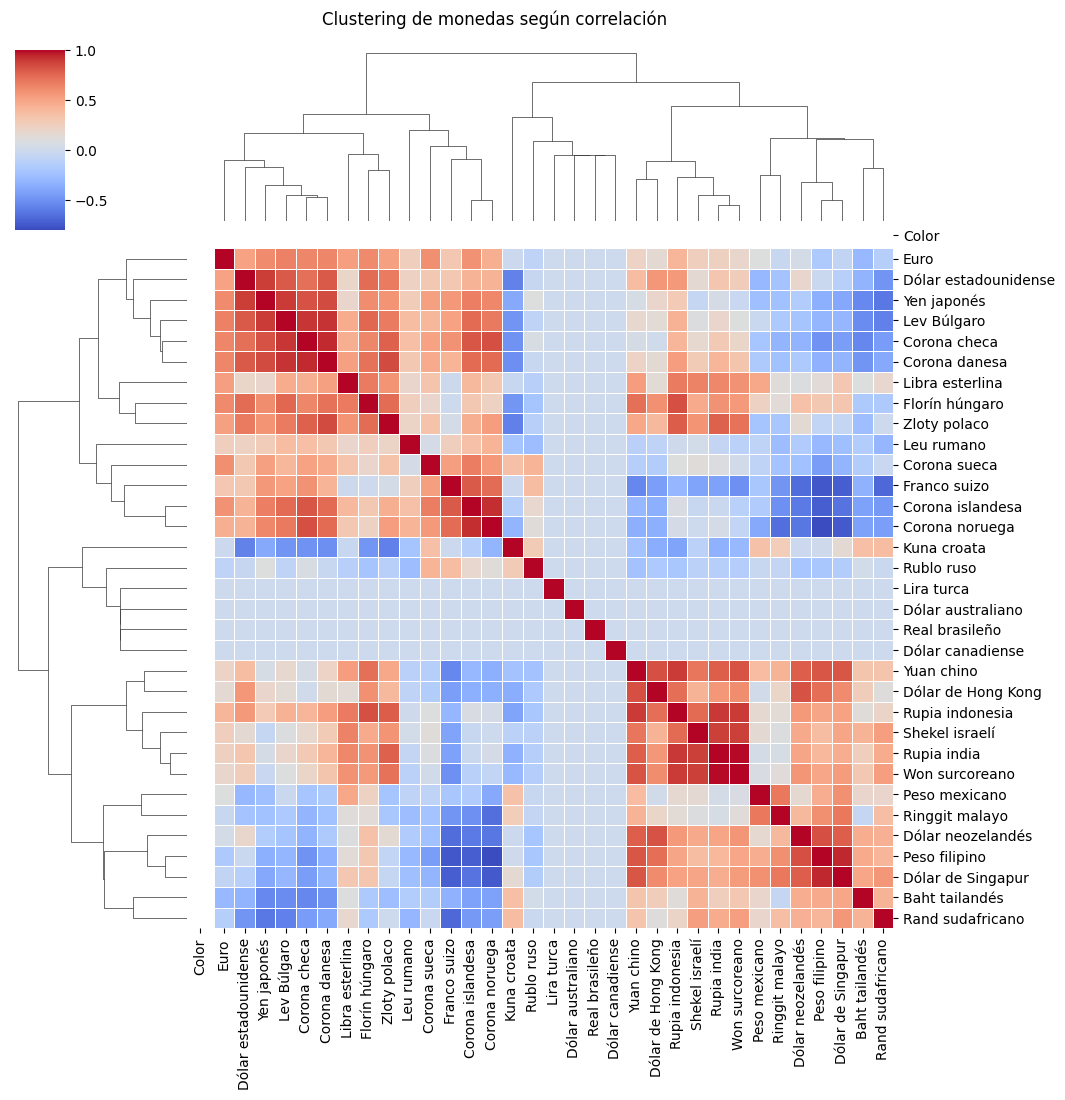

In [ ]:
# 1️. Rellenar valores NaN antes de calcular la correlación
# Nota: Esto lo hago dado que kmeans no acepta valores NaN
df_monedas = df_monedas.fillna(df_monedas.mean())

# 2️. Calcular la matriz de correlación asegurando una diagonal correcta (1)
correlacion_monedas = df_monedas.corr(min_periods=1)
np.fill_diagonal(correlacion_monedas.values, 1)
# Rellenar los posibles NaN que surjan en la matriz de correlación
correlacion_monedas = correlacion_monedas.fillna(0)

# 3️. Revisar la diagonal después de estos ajustes
print("Diagonal después de ajustes:")
print(np.diag(correlacion_monedas))

# 4️. Aplicar K-Means clustering sobre los valores de correlación
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(correlacion_monedas)

# 5️. Crear un DataFrame con los clusters asignados
df_clusters = pd.DataFrame(
    {'Moneda': correlacion_monedas.index, 'Cluster': labels})

# 6️. Definir colores únicos por cluster
colores_clusters = {i: plt.cm.viridis(
    i / num_clusters) for i in range(num_clusters)}
df_clusters['Color'] = df_clusters['Cluster'].map(colores_clusters)

# 7️. Diccionario de nombres largos de monedas
equivalencias_monedas = {
    "AUD_value": "Dólar australiano", "BRL_value": "Real brasileño",
    "CAD_value": "Dólar canadiense",
    "CHF_value": "Franco suizo", "CNY_value": "Yuan chino",
    "CZK_value": "Corona checa",
    "DKK_value": "Corona danesa", "GBP_value": "Libra esterlina",
    "HKD_value": "Dólar de Hong Kong",
    "HUF_value": "Florín húngaro", "IDR_value": "Rupia indonesia",
    "ILS_value": "Shekel israelí",
    "INR_value": "Rupia india", "ISK_value": "Corona islandesa",
    "JPY_value": "Yen japonés",
    "KRW_value": "Won surcoreano", "MXN_value": "Peso mexicano",
    "MYR_value": "Ringgit malayo",
    "NOK_value": "Corona noruega", "NZD_value": "Dólar neozelandés",
    "PHP_value": "Peso filipino",
    "PLN_value": "Zloty polaco", "RON_value": "Leu rumano",
    "SEK_value": "Corona sueca",
    "SGD_value": "Dólar de Singapur", "THB_value": "Baht tailandés",
    "TRY_value": "Lira turca",
    "USD_value": "Dólar estadounidense", "ZAR_value": "Rand sudafricano",
    "BGN_value": "Lev Búlgaro", "HRK_value": "Kuna croata",
    "RUB_value": "Rublo ruso", "EUR_value": "Euro"}


# 8️. Obtener nombres largos de las monedas en el mismo orden que
monedas_actuales = correlacion_monedas.index.tolist()
nombres_largos_filtrados = [
    equivalencias_monedas.get(m, m) for m in monedas_actuales]


# 9️. Crear el clustermap con colores en filas y columnas según los clusters
plt.figure(figsize=(12, 8))
clustermap = sns.clustermap(
    correlacion_monedas,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5,
    row_colors=df_clusters['Color'],  # Colores en filas según clusters
    col_colors=df_clusters['Color']   # Colores en columnas según clusters
)

# 10. Ajustar etiquetas para mostrar los nombres largos de las monedas
clustermap.ax_heatmap.set_yticklabels(
    nombres_largos_filtrados, fontsize=10)
clustermap.ax_heatmap.set_xticklabels(
    nombres_largos_filtrados, fontsize=10, rotation=90)

# 1️1. Título del gráfico
clustermap.fig.suptitle("Clustering de monedas según correlación", y=1.02)

# 1️2. Mostrar el gráfico
plt.show()

# Análisis de los clusters de monedas correladas

El*Cluster 0* incluye monedas como el dólar estadounidense (USD), el yuan chino (CNY), el dólar de Hong Kong (HKD), la rupia india (INR), el peso filipino (PHP) y el rand sudafricano (ZAR). Estas monedas muestran correlaciones significativas con mercados emergentes y tienen una relación estrecha con el comportamiento del dólar estadounidense como referencia global.

El *Cluster 1* agrupa monedas como el euro (EUR), el lev búlgaro (BGN), la corona checa (CZK), la corona sueca (SEK), la kuna croata (HRK). Este cluster sugiere una influencia predominante de la zona euro.

El *Cluster 2* está compuesto por la corona danesa (DKK), el florín húngaro (HUF), el leu rumano (RON), la corona noruega (NOK), la lira turca (TRY), el dólar australiano (AUD), el real brasileño (BRL), el dólar canadiense (CAD), el won surcoreano (KRW), el peso mexicano (MXN) y el dólar neozelandés (NZD).

El *Cluster 3* reúne el yen japonés (JPY), la libra esterlina (GBP), el zloty polaco (PLN), el franco suizo (CHF), la corona islandesa (ISK), el ringgit malayo (MYR) y el baht tailandés (THB).

### Ejercicio 3 ( 1 punto)



Crea una visualización en forma de grafo utilizando la librería `networkx` para representar las correlaciones entre monedas obtenidas a partir del dataframe de correlaciones. Sólo considera aquellas correlaciones con valor absoluto superior o igual a `0.3`. El grafo debe cumplir los siguientes requisitos:

1. Cada nodo debe representar una moneda, identificada por su código corto, pero con el nombre completo como etiqueta.
2. Añade una arista entre dos monedas sólo si su correlación es ≥ 0.3 o ≤ -0.3.
3. El ancho de las aristas debe ser proporcional a la fuerza de la correlación.
4. Las aristas deben ser verdes si la correlación es positiva y rojas si es negativa.
5. Usa el layout `kamada_kawai_layout` para disponer los nodos y muestra el grafo con `matplotlib`.


<span style="fuente-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 3px; ">EG</span>
**(1 punto)**


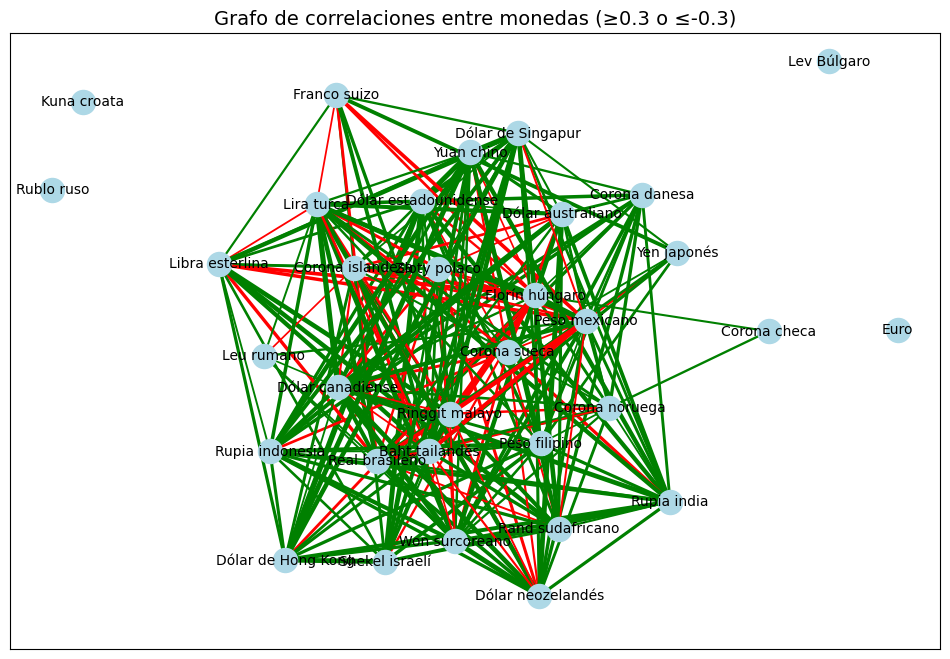

In [ ]:
# 1️. Crear el grafo vacío
G = nx.Graph()

# 2️. Agregar nodos con nombres largos como etiquetas
for moneda in correlacion_monedas.columns:
    G.add_node(moneda, label=equivalencias_monedas.get(moneda, moneda))

# 3️. Agregar aristas con peso proporcional a la correlación
for moneda1 in correlacion_monedas.columns:
    for moneda2 in correlacion_monedas.columns:
        if moneda1 != moneda2:  # Evitar relaciones consigo misma
            corr_value = correlacion_monedas.loc[moneda1, moneda2]
            if abs(corr_value) >= 0.3:  # Filtrar correlaciones fuertes
                G.add_edge(
                    moneda1, moneda2, weight=abs(corr_value),
                    color="green" if corr_value > 0 else "red")

# 4️. Organizar los nodos con el layout kamada_kawai
pos = nx.kamada_kawai_layout(G)

# Obtener el grosor de las aristas proporcional a la correlación (escalar)
edge_weights = [G[u][v]['weight'] * 4 for u, v in G.edges()]
edge_colors = [G[u][v]['color'] for u, v in G.edges()]

# 5️. Dibujar el grafo
plt.figure(figsize=(12, 8))
nx.draw_networkx(
    G,
    pos,
    labels={n: G.nodes[n]["label"] for n in G.nodes()},
    node_color="lightblue",
    edge_color=edge_colors,
    width=edge_weights,
    with_labels=True,
    font_size=10,
    font_color="black"
)

plt.title("Grafo de correlaciones entre monedas (≥0.3 o ≤-0.3)", fontsize=14)
plt.show()

### Ejercicio 4 ( 1 punto)

En los ejercicios anteriores, hemos utilizado directamente una API para realizar solicitudes a servicios online, y nos encargamos directamente de la gestión de los datos de salida.

Sin embargo, también hemos visto en los materiales del curso el uso de librerías que facilitan el acceso a una API, como *tweepy*.

La mayoría de estas librerías (y la mayoría de APIs de proyectos populares) requieren un registro en una web de desarrolladores o API Key.

En este ejercicio le proponemos el uso de geopy https://geopy.readthedocs.io en conjunción con una API, Open Notify, que contiene la información tanto sobre los humanos residentes fuera de la tierra (es decir, en el espacio) como de la posición de la estación internacional Espacial. [Open Notify](http://api.open-notify.org).

Programa una función que obtenga la longitud y latitud de la posición sobre la que está volando la ISS. Calcula, de forma aproximada su velocidad (suponiendo que estuviera en la superficie de la tierra), obteniendo dos localizaciones consecutivas dentro de un intervalo de tiempo, y calculando la distancia entre éstas.

Puedes guiarte con estas dos funciones:

- la función `sleep` del módulo `time`, para pausar un número de segundos.
- la función `distance` del módulo `geopy.distance` para calcular la distancia entre dos localizaciones en el globo.


**(1 punto)** <span style="fuente-family: Courier New; background-color: #ffcc5c; color: #000000; padding: 2px; ">EG</span>

In [ ]:
# 1️. Definir la función que obtiene la posición actual de la ISS
def obtener_posicion_ISS():
    """
    Obtiene la latitud y longitud de la ISS desde la API Open Notify.
    """
    url = "http://api.open-notify.org/iss-now.json"
    response = requests.get(url)

    if response.status_code == 200:
        datos = response.json()
        lat = float(datos["iss_position"]["latitude"])
        lon = float(datos["iss_position"]["longitude"])
        return (lat, lon)
    else:
        print("Error al obtener la posición de la ISS.")
        return None

# 2️. Definir la función que calcula la velocidad de la ISS
def calcular_velocidad_ISS(intervalo=10):
    """
    Calcula la velocidad aproximada de la ISS basándose en la distancia
    recorrida en un intervalo de tiempo (por defecto, 10 segundos).
    """
    print("Obteniendo primera posición de la ISS...")
    posicion_1 = obtener_posicion_ISS()

    if not posicion_1:
        return

    time.sleep(intervalo)

    print("Obteniendo segunda posición de la ISS...")
    posicion_2 = obtener_posicion_ISS()

    if not posicion_2:
        return

    # 3️. Calcular la distancia en km entre ambas posiciones usando geopy
    distancia_km = geodesic(posicion_1, posicion_2).km

    # 4️. Calcular la velocidad en km/h
    # Multiplicamos por 3600 para convertir km/s a km/h
    velocidad_kmh = (distancia_km / intervalo) * 3600

    # 5️. Mostrar los resultados en pantalla
    print(f" Distancia recorrida: {distancia_km:.2f} km")
    print(f" Velocidad aproximada de la ISS: {velocidad_kmh:.2f} km/h")

# 6️. Ejecutar la función para calcular la velocidad
calcular_velocidad_ISS(intervalo=10)

Obteniendo primera posición de la ISS...
Obteniendo segunda posición de la ISS...
 Distancia recorrida: 69.10 km
 Velocidad aproximada de la ISS: 24877.73 km/h


### Ejercicio 5 (2 puntos)

Considera el archivo `evolucion.csv`. A partir del archivo:

a) importa el archivo a pandas y descríbelo. <span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(0,5 puntos)**


Nota: Puedes utilizar el módulo `datetime` para procesar la columna de fechas.


In [ ]:
# 1. Definir la ruta del archivo
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Activity_5/data/evolucion.csv"

# 2. Cargar el archivo CSV en un DataFrame
df = pd.read_csv(ruta_archivo)

# 3. Mostrar información básica del DataFrame
print("Información del archivo:")
print(df.info())  # Tipos de datos y valores nulos

# 4.Mostrar las primeras filas para comprobar los datos
print("\n Primeras filas del DataFrame:")
print(df.head(7))

Información del archivo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26447 entries, 0 to 26446
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Fecha           26447 non-null  object
 1   cod_ine         26447 non-null  int64 
 2   provincia       26447 non-null  object
 3   Casos           26447 non-null  int64 
 4   Fallecidos      26447 non-null  int64 
 5   Hospitalizados  26447 non-null  int64 
 6   UCI             26447 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.4+ MB
None

 Primeras filas del DataFrame:
        Fecha  cod_ine         provincia  Casos  Fallecidos  Hospitalizados  \
0  2020-01-01        0         No consta      0           0               0   
1  2020-01-01        1       Araba/Álava      0           0               0   
2  2020-01-01        2          Albacete      0           0               0   
3  2020-01-01        3  Alicante/Alacant      0           0         

In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"])  # Convertimos la columna al tipo datetime
print(df.info())  # Verificamos que la conversión fue exitosa


b) Usa ipywidgets para realizar un pequeño panel de datos en el que:
- Puedas seleccionar una o más provincias disponibles basadas en los datos leídos con un widget
- Puedas seleccionar una o más de las curvas disponibles con un segundo widget
- Crea un panel interactivo en el que al seleccionar las provincias y curvas a representar, se cree una figura mostrando la evolución de las curvas seleccionadas a lo largo del tiempo.
- Dentro de esta función, se filtra los datos en función de las provincias seleccionadas y se trazan las curvas correspondientes para cada provincia. Por último, se configura el estilo de la gráfica, se muestran las etiquetas y el título, y se muestra la gráfica.

Recuerda etiquetar los plotes, ejes e incluir leyendas.

<span style="fuente-family: Courier New; background-color: #82b74b; color: #000000; padding: 3px; ">NM</span> **(1.5 puntos)**

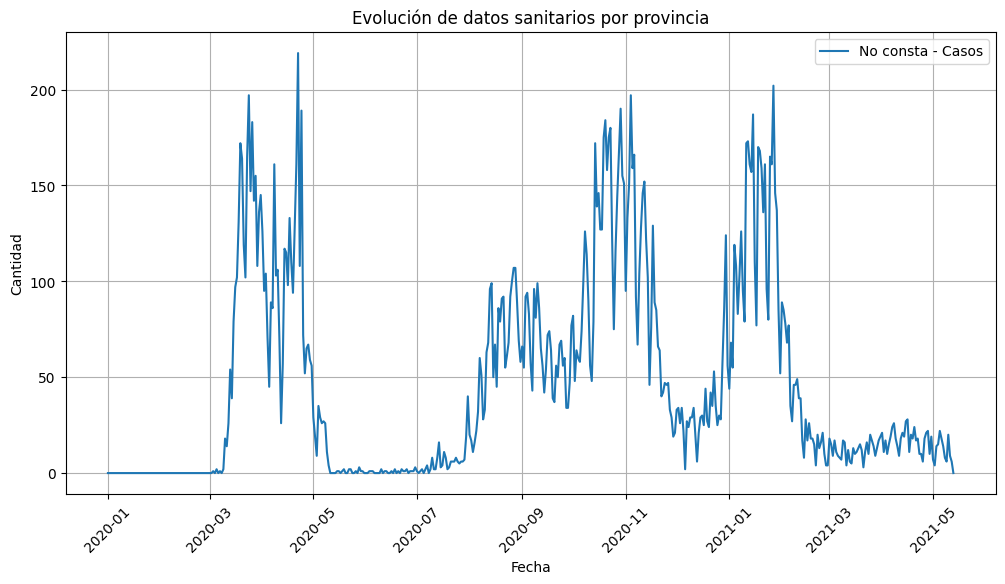

In [ ]:
# 1. Crear widgets para seleccionar provincias y curvas
provincias = df["provincia"].unique()
curvas = ["Casos", "Fallecidos", "Hospitalizados", "UCI"]

provincia_widget = widgets.SelectMultiple(
    options=provincias,
    value=[provincias[0]],  # Selección por defecto
    description="Provincia",
    layout={'width': '50%'}
)

curva_widget = widgets.SelectMultiple(
    options=curvas,
    value=["Casos"],  # Selección por defecto
    description="Curva",
    layout={'width': '50%'}
)

# 2. Función para graficar los datos según la selección del usuario
def graficar_evolucion(provincias_seleccionadas, curvas_seleccionadas):
    plt.figure(figsize=(12, 6))

    for provincia in provincias_seleccionadas:
        df_filtrado = df[
            df["provincia"] == provincia]  # Filtrar datos por provincia

        for curva in curvas_seleccionadas:
            plt.plot(
                df_filtrado["Fecha"], df_filtrado[curva],
                label=f"{provincia} - {curva}")

    # 3. Configurar estilo de la gráfica
    plt.xlabel("Fecha")
    plt.ylabel("Cantidad")
    plt.title("Evolución de datos sanitarios por provincia")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()

# 4. Crear una interfaz interactiva con widgets
widget_interactivo = widgets.interactive(
    graficar_evolucion,
    provincias_seleccionadas=provincia_widget,
    curvas_seleccionadas=curva_widget
)

# 5. Mostrar la interfaz interactiva
display(widget_interactivo)

### Ejercicio Opcional

Dada la serie

$$z_n = z_{n-1}^5 + c$$
y dada un elemento inicial de la serie $z_0 = 0+i0$

1. Escribe una función $f(c, A, N_{max})$, que devuelva el número iteraciones $N$ de la serie anterior necesarias para que el módulo $|z|> A$, siendo $A \in {\rm I\!R}$.
2. Calcula y representa una imagen 2D representando $N$ sobre el dominio de $c$ compras por $Re(c) \subset [-2,1]$, $Im(c) \subset [-1,1]$ con los parámetros
($A=2$, $n_{max}=100$, $z_0 = i0$, Resolución de la imagen =
(800,1200) pixels).

Nota: Puede ser útil la función `meshgrid` de `numpy`.

<span style="fuente-family: Courier New; background-color: #f2ae72; color: #000000; padding: 3px; ">EI</span>

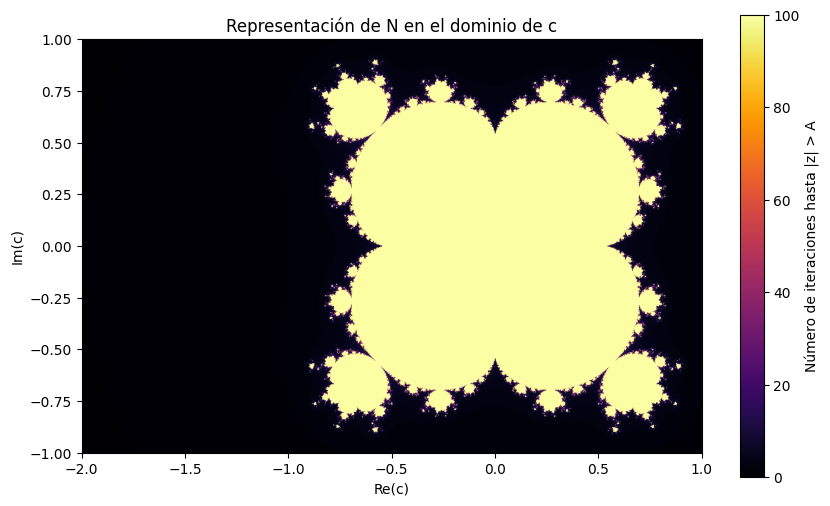

In [ ]:
# 1️. Definir la función que calcula el número de iteraciones hasta que |z| > A
def f(c, A, Nmax):
    z = 0 + 1j * 0
    for N in range(Nmax):
        z = z**5 + c
        if abs(z) > A:
            return N
    return Nmax

# 2️. Definir el dominio de c (parte real e imaginaria)
res_x, res_y = 1200, 800
x = np.linspace(-2, 1, res_x)
y = np.linspace(-1, 1, res_y)

# 3️. Crear la malla de valores con meshgrid
X, Y = np.meshgrid(x, y)
C = X + 1j * Y

# 4️. Calcular N para cada punto de c
N_values = np.zeros_like(X, dtype=int)

for i in range(res_y):  # Iteramos sobre filas
    for j in range(res_x):  # Iteramos sobre columnas
        N_values[i, j] = f(C[i, j], A=2, Nmax=100)

# 5️. Visualizar la imagen 2D con Matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(N_values, cmap="inferno", extent=[-2, 1, -1, 1], origin="lower")
plt.colorbar(label="Número de iteraciones hasta |z| > A")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.title("Representación de N en el dominio de c")
plt.show()

Este ejercicio ha permitido explorar la evolución de la serie $$ z_n = z_{n-1}^5 + c $$
en el plano complejo.
Se ha implementado una función para calcular el número de iteraciones necesarias para que |z| > A,  y se ha generado una representación visual de N sobre el dominio de c.

Esta representación guarda relación con el conjunto de Mandelbrot, donde ciertos valores de c generan patrones fractales y estructuras complejas, permitiendo estudiar zonas de estabilidad y caos matemático.

## Bibliografía

* Geopy. (n.d.). GeoPy’s documentation. Retrieved April 2025, from [https://geopy.readthedocs.io](https://geopy.readthedocs.io)  
* Open Notify. (n.d.). Retrieved April 2025, from [http://api.open-notify.org](http://api.open-notify.org)  
* Vatcomply. (n.d.). VAT Validation. Retrieved April 2025, from [https://vatcomply.com](https://vatcomply.com)  
* Wikipedia contributors. (2025, April 7). *Conjunto de Mandelbrot*. Wikipedia, The Free Encyclopedia. Retrieved April 2025, from [https://en.wikipedia.org/wiki/Mandelbrot_set]
